# Audio to Spectrogram Conversion

This notebook converts WAV audio files from the Fake-or-Real (FoR) dataset into mel spectrograms for training deepfake audio detection models.

## Pipeline:
1. Load WAV audio files using librosa
2. Generate mel spectrograms
3. Convert to dB scale
4. Save as 224x224 PNG images

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
# Paths configuration
BASE_DIR = Path('../')
AUDIO_DIR = BASE_DIR / 'data' / 'Deepfake-Audio-Detection-with-XAI'
SPECTROGRAM_DIR = BASE_DIR / 'data' / 'spectrograms'

# Dataset splits
SPLITS = ['training', 'validation', 'testing']
CLASSES = ['fake', 'real']

# Spectrogram parameters
SAMPLE_RATE = 22050  # Default librosa sample rate
N_MELS = 128  # Number of mel bands
HOP_LENGTH = 512  # Hop length for STFT
N_FFT = 2048  # FFT window size

print(f"Audio source directory: {AUDIO_DIR}")
print(f"Spectrogram output directory: {SPECTROGRAM_DIR}")

Audio source directory: ../data/Deepfake-Audio-Detection-with-XAI
Spectrogram output directory: ../data/spectrograms


## Define Spectrogram Generation Functions

In [3]:
def create_spectrogram(audio_file: str, output_file: str, figsize=(2.24, 2.24), dpi=100) -> bool:
    """
    Create a mel spectrogram image from an audio file.
    
    Args:
        audio_file: Path to the input WAV file
        output_file: Path to save the output PNG image
        figsize: Figure size (width, height) in inches
        dpi: Dots per inch (figsize * dpi = pixel dimensions)
    
    Returns:
        True if successful, False otherwise
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
        
        # Generate mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, 
            sr=sr, 
            n_mels=N_MELS,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH
        )
        
        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Create figure without axes for clean image
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = fig.add_subplot(1, 1, 1)
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        
        # Display spectrogram
        librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP_LENGTH)
        
        # Remove axes
        ax.axis('off')
        
        # Save figure
        fig.savefig(output_file, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        
        return True
    except Exception as e:
        print(f"Error processing {audio_file}: {e}")
        return False

In [4]:
def convert_directory(input_dir: Path, output_dir: Path) -> tuple:
    """
    Convert all WAV files in a directory to spectrograms.
    
    Args:
        input_dir: Directory containing WAV files
        output_dir: Directory to save spectrogram images
    
    Returns:
        Tuple of (success_count, error_count)
    """
    # Create output directory if it doesn't exist
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Get all WAV files
    wav_files = list(input_dir.glob('*.wav'))
    
    success_count = 0
    error_count = 0
    
    for wav_file in tqdm(wav_files, desc=f"Processing {input_dir.name}"):
        # Generate output filename (replace .wav with .png)
        output_file = output_dir / (wav_file.stem + '.png')
        
        # Skip if already exists
        if output_file.exists():
            success_count += 1
            continue
        
        if create_spectrogram(str(wav_file), str(output_file)):
            success_count += 1
        else:
            error_count += 1
    
    return success_count, error_count

## Verify Dataset Structure

In [5]:
# Check that audio directories exist and count files
print("Dataset structure verification:\n")

total_files = 0
for split in SPLITS:
    print(f"\n{split.upper()}:")
    for cls in CLASSES:
        dir_path = AUDIO_DIR / split / cls
        if dir_path.exists():
            wav_count = len(list(dir_path.glob('*.wav')))
            total_files += wav_count
            print(f"  {cls}: {wav_count} files")
        else:
            print(f"  {cls}: Directory not found!")

print(f"\nTotal audio files: {total_files}")

Dataset structure verification:


TRAINING:
  fake: 6978 files
  real: 6978 files

VALIDATION:
  fake: 1413 files
  real: 1413 files

TESTING:
  fake: 544 files
  real: 544 files

Total audio files: 17870


## Preview Sample Spectrogram

Sample audio file: file9328.wav_16k.wav_norm.wav_mono.wav_silence.wav_2sec.wav


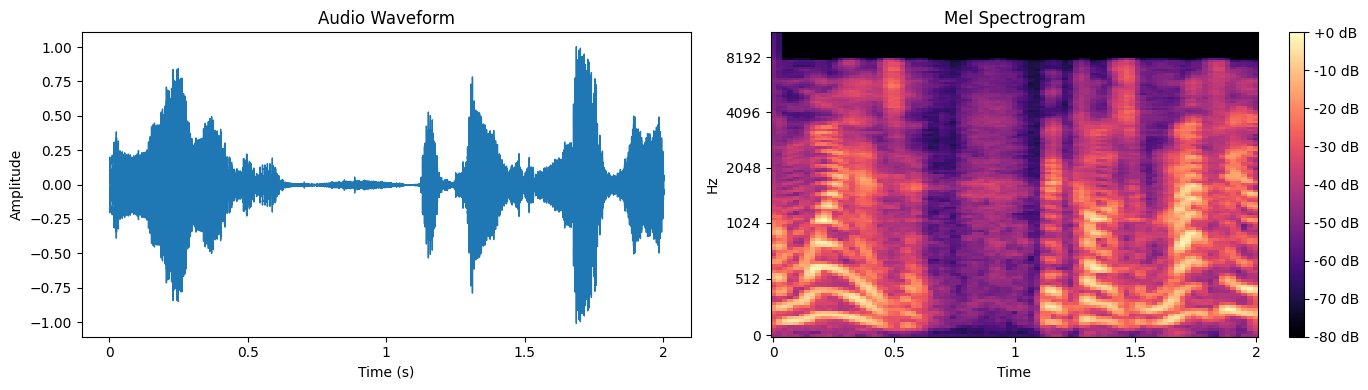

In [6]:
# Generate a sample spectrogram for preview
sample_dir = AUDIO_DIR / 'training' / 'real'
sample_files = list(sample_dir.glob('*.wav'))[:1]

if sample_files:
    sample_file = sample_files[0]
    print(f"Sample audio file: {sample_file.name}")
    
    # Load and display
    y, sr = librosa.load(str(sample_file), sr=SAMPLE_RATE)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Waveform
    axes[0].set_title('Audio Waveform')
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    
    # Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    axes[1].set_title('Mel Spectrogram')
    img = librosa.display.specshow(mel_spec_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=axes[1])
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
else:
    print("No sample files found!")

## Convert All Audio Files to Spectrograms

This cell will process all audio files and save spectrograms. This may take several minutes depending on the dataset size.

In [7]:
# Convert all audio files to spectrograms
print("Converting audio files to spectrograms...\n")

total_success = 0
total_errors = 0

for split in SPLITS:
    print(f"\n{'='*50}")
    print(f"Processing {split.upper()} set")
    print('='*50)
    
    for cls in CLASSES:
        input_dir = AUDIO_DIR / split / cls
        output_dir = SPECTROGRAM_DIR / split / cls
        
        if input_dir.exists():
            success, errors = convert_directory(input_dir, output_dir)
            total_success += success
            total_errors += errors
            print(f"  {cls}: {success} successful, {errors} errors")
        else:
            print(f"  {cls}: Skipped (directory not found)")

print(f"\n{'='*50}")
print(f"CONVERSION COMPLETE")
print(f"Total: {total_success} successful, {total_errors} errors")
print('='*50)

Converting audio files to spectrograms...


Processing TRAINING set


Processing fake: 100%|██████████| 6978/6978 [01:08<00:00, 101.74it/s]


  fake: 6978 successful, 0 errors


Processing real: 100%|██████████| 6978/6978 [01:22<00:00, 84.90it/s] 


  real: 6978 successful, 0 errors

Processing VALIDATION set


...

  real: 1413 successful, 0 errors

Processing TESTING set


Processing fake: 100%|██████████| 544/544 [00:05<00:00, 97.98it/s] 


  fake: 544 successful, 0 errors


Processing real: 100%|██████████| 544/544 [00:15<00:00, 34.69it/s] 

  real: 544 successful, 0 errors

CONVERSION COMPLETE
Total: 17870 successful, 0 errors


## Verify Generated Spectrograms

In [8]:
# Count generated spectrograms
print("Generated spectrogram counts:\n")

for split in SPLITS:
    print(f"\n{split.upper()}:")
    for cls in CLASSES:
        spec_dir = SPECTROGRAM_DIR / split / cls
        if spec_dir.exists():
            png_count = len(list(spec_dir.glob('*.png')))
            print(f"  {cls}: {png_count} spectrograms")
        else:
            print(f"  {cls}: No directory")

Generated spectrogram counts:


TRAINING:
  fake: 6978 spectrograms
  real: 6978 spectrograms

VALIDATION:
  fake: 1413 spectrograms
  real: 1413 spectrograms

TESTING:
  fake: 544 spectrograms
  real: 544 spectrograms


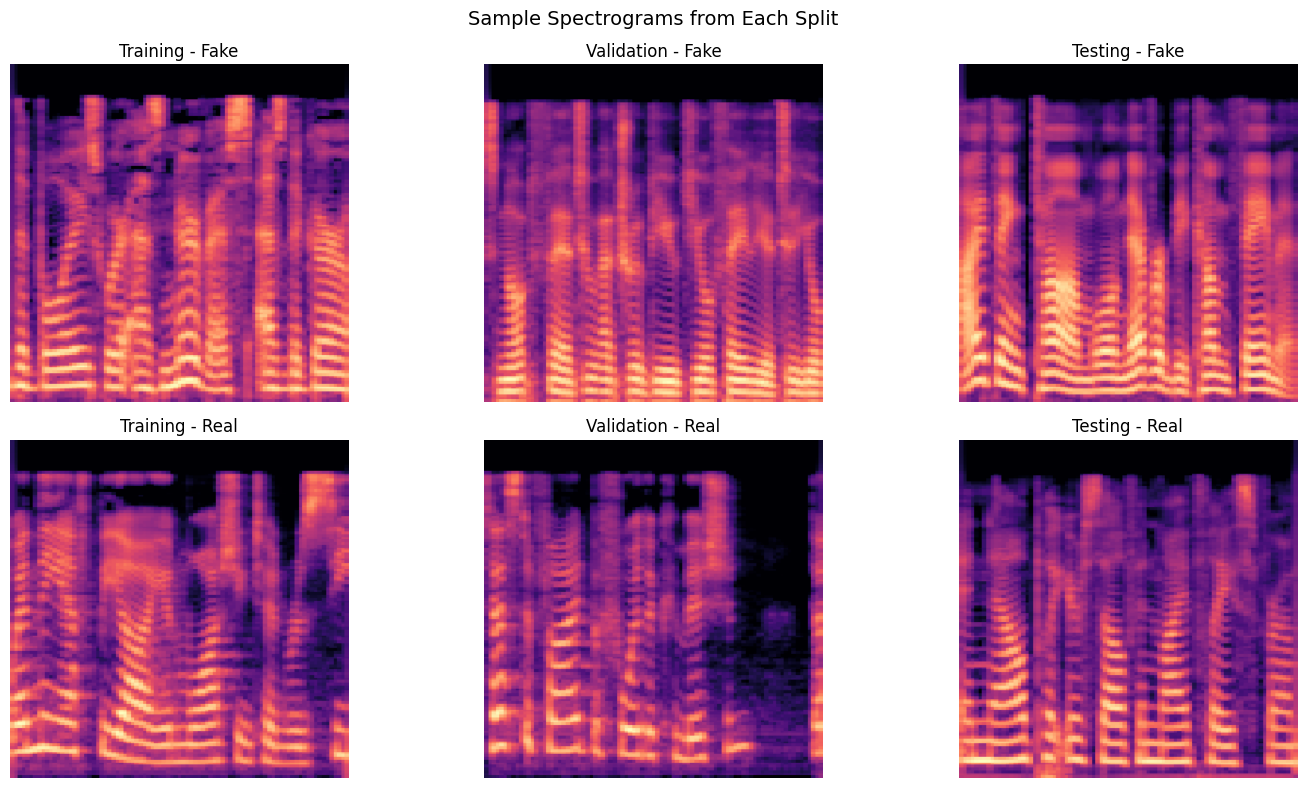

In [9]:
# Display sample spectrograms from each class
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, cls in enumerate(CLASSES):
    for j, split in enumerate(SPLITS):
        spec_dir = SPECTROGRAM_DIR / split / cls
        if spec_dir.exists():
            png_files = list(spec_dir.glob('*.png'))
            if png_files:
                img = Image.open(png_files[0])
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{split.capitalize()} - {cls.capitalize()}")
                axes[i, j].axis('off')

plt.suptitle('Sample Spectrograms from Each Split', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

Spectrograms have been generated and saved to `data/spectrograms/`. The directory structure is:

```
data/spectrograms/
├── training/
│   ├── fake/
│   └── real/
├── validation/
│   ├── fake/
│   └── real/
└── testing/
    ├── fake/
    └── real/
```

These spectrograms are ready to be used for training the audio classification models in the subsequent notebooks.